In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer


In [10]:
# load the dataset

df = pd.read_csv("../data/raw/personality_dataset.csv")

In [11]:
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [12]:
df.sample(10)

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
870,9.0,Yes,1.0,1.0,Yes,0.0,1.0,Introvert
712,7.0,Yes,2.0,1.0,Yes,4.0,0.0,Introvert
2253,3.0,No,8.0,4.0,No,13.0,6.0,Extrovert
897,8.0,Yes,3.0,1.0,Yes,0.0,1.0,Introvert
2379,2.0,No,9.0,3.0,No,14.0,7.0,Extrovert
2011,0.0,No,5.0,NaN,No,11.0,9.0,Extrovert
2803,2.0,No,4.0,5.0,No,5.0,7.0,Extrovert
2746,7.0,Yes,2.0,2.0,Yes,2.0,2.0,Introvert
2802,5.0,Yes,0.0,0.0,Yes,4.0,2.0,Introvert
2530,2.0,No,7.0,3.0,No,15.0,9.0,Extrovert


In [13]:
# Dataset inspection

df.shape

(2900, 8)

In [14]:
# columns names

df.columns

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='str')

In [15]:
# data types

df.dtypes

Time_spent_Alone             float64
Stage_fear                       str
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing        str
Friends_circle_size          float64
Post_frequency               float64
Personality                      str
dtype: object

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   str    
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   str    
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 181.4 KB


In [17]:
# Find the Missing Values

df.isnull().sum()

Time_spent_Alone             63
Stage_fear                   73
Social_event_attendance      62
Going_outside                66
Drained_after_socializing    52
Friends_circle_size          77
Post_frequency               65
Personality                   0
dtype: int64

In [18]:
# missing values presentages

missing_pct = (
    df.isnull().sum() /
    len(df)
) * 100

missing_pct.sort_values(
    ascending=False
)

Friends_circle_size          2.655172
Stage_fear                   2.517241
Going_outside                2.275862
Post_frequency               2.241379
Time_spent_Alone             2.172414
Social_event_attendance      2.137931
Drained_after_socializing    1.793103
Personality                  0.000000
dtype: float64

In [19]:
# checking duplicates values

df.duplicated().sum()

np.int64(388)

In [20]:
# uniques values

for col in df.columns:
    print(col)
    print(df[col].nunique())
    print()

Time_spent_Alone
12

Stage_fear
2

Social_event_attendance
11

Going_outside
8

Drained_after_socializing
2

Friends_circle_size
16

Post_frequency
11

Personality
2



In [21]:
# Target distribution

df["Personality"].value_counts()

Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64

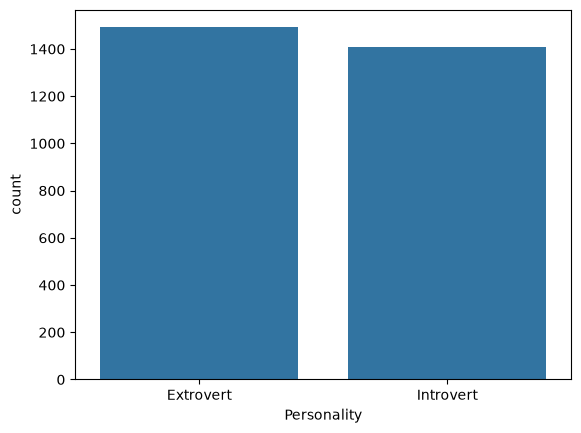

In [22]:
# visualize

sns.countplot(
    data=df,
    x="Personality"
)
plt.show()

In [23]:
## Statistical Summary
## Numerical columns

df.describe()

,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2837.000000,2838.000000,2834.000000,2823.000000,2835.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.479192,2.903827,2.247327,4.289693,2.926582
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.000000,3.000000,5.000000,3.000000
75%,8.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


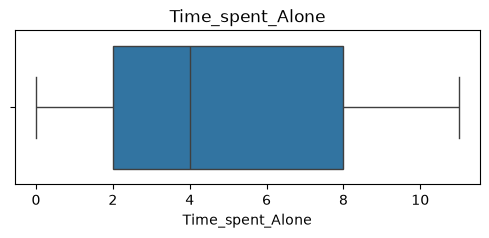

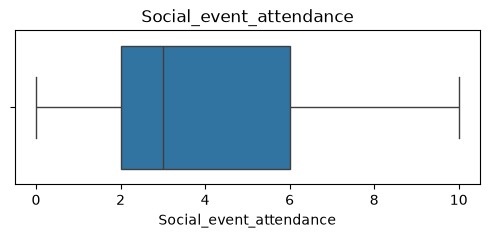

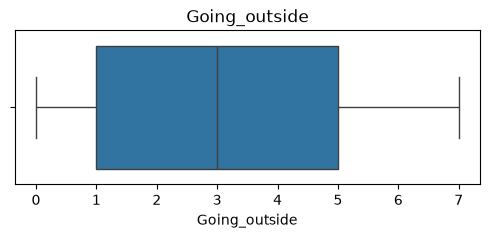

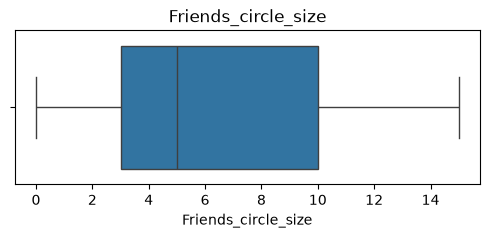

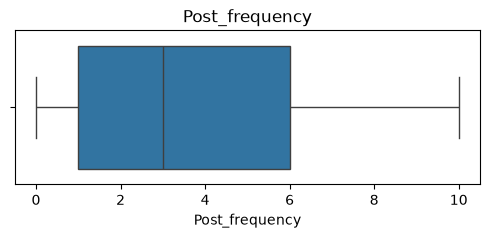

In [24]:
# Outlier Detection
# Boxplots

numeric_cols = df.select_dtypes(
    include=np.number
).columns

for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(
        x=df[col]
    )
    plt.title(col)
    plt.show()

In [25]:
# IQR method

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

In [26]:
# Count outliers

outliers = (
    (
        df[numeric_cols] <
        (Q1 - 1.5*IQR)
    ) |
    (
        df[numeric_cols] >
        (Q3 + 1.5*IQR)
    )
)

outliers.sum()

Time_spent_Alone           0
Social_event_attendance    0
Going_outside              0
Friends_circle_size        0
Post_frequency             0
dtype: int64

In [27]:
# Exploratory Data Analysis

<Axes: xlabel='Personality', ylabel='count'>

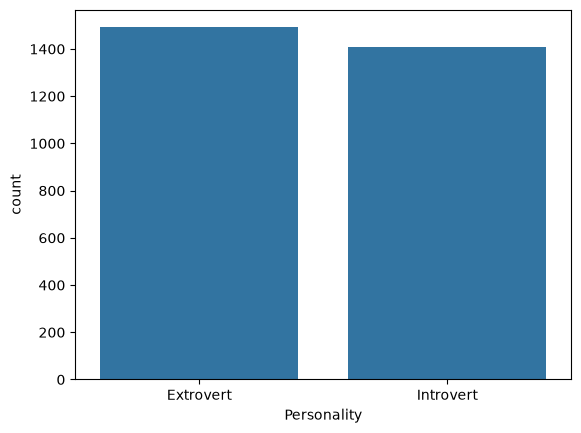

In [28]:
# Personality Distribution

sns.countplot(
    x="Personality",
    data=df
)

<Axes: xlabel='Personality', ylabel='Time_spent_Alone'>

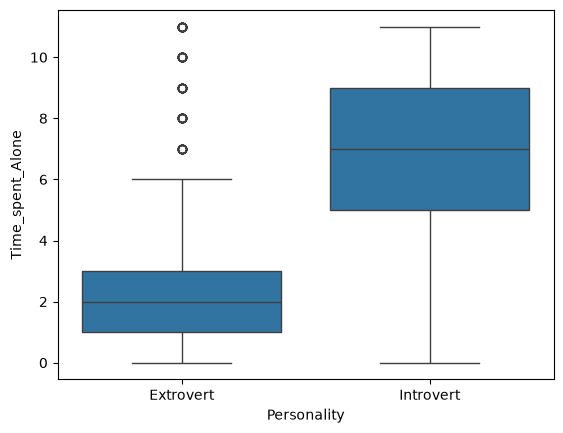

In [29]:
# Time Alone vs Personality

sns.boxplot(
    x="Personality",
    y="Time_spent_Alone",
    data=df
)

<Axes: xlabel='Personality', ylabel='Social_event_attendance'>

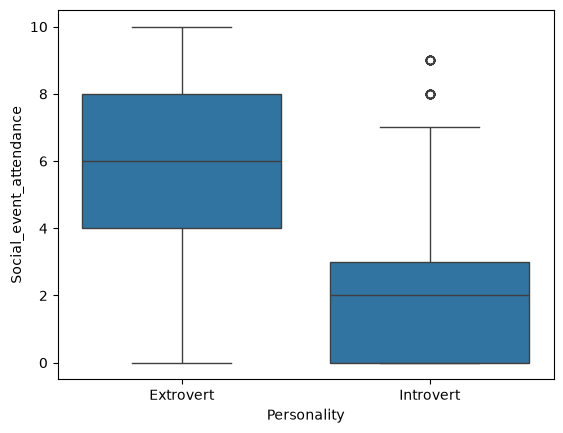

In [30]:
# Social Events vs Personality

sns.boxplot(
    x="Personality",
    y="Social_event_attendance",
    data=df
)

<Axes: xlabel='Personality', ylabel='Friends_circle_size'>

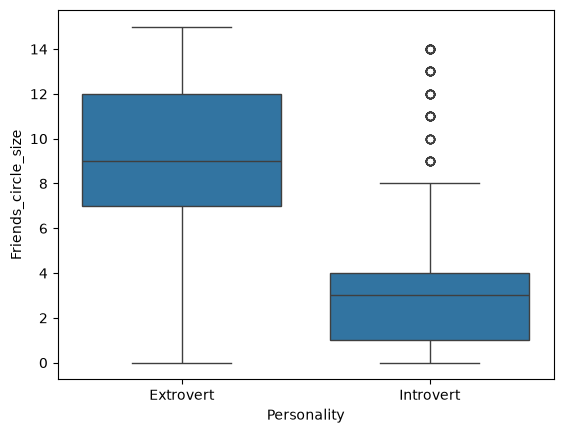

In [31]:
# Friend Circle Size

sns.boxplot(
    x="Personality",
    y="Friends_circle_size",
    data=df
)

<Axes: xlabel='Stage_fear', ylabel='count'>

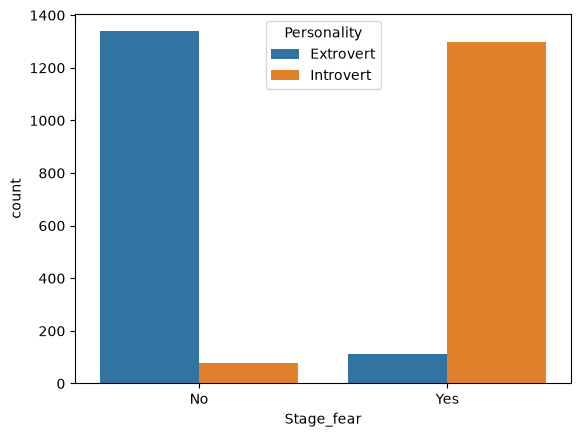

In [32]:
# Stage Fear Analysis

pd.crosstab(
    df["Stage_fear"],
    df["Personality"]
)

sns.countplot(
    x="Stage_fear",
    hue="Personality",
    data=df
)

In [33]:
# Correlation Analysis 
# Encode temporary copy

eda_df = df.copy()

In [34]:
# Convert categories

for col in eda_df.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    eda_df[col] = le.fit_transform(eda_df[col])
    print(f"Encoded column: {col} | Unique values: {eda_df[col].nunique()}")

Encoded column: Stage_fear | Unique values: 3
Encoded column: Drained_after_socializing | Unique values: 3
Encoded column: Personality | Unique values: 2


C:\Users\USER\AppData\Local\Temp\ipykernel_25484\1375071229.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in eda_df.select_dtypes(include=['object', 'category']).columns:


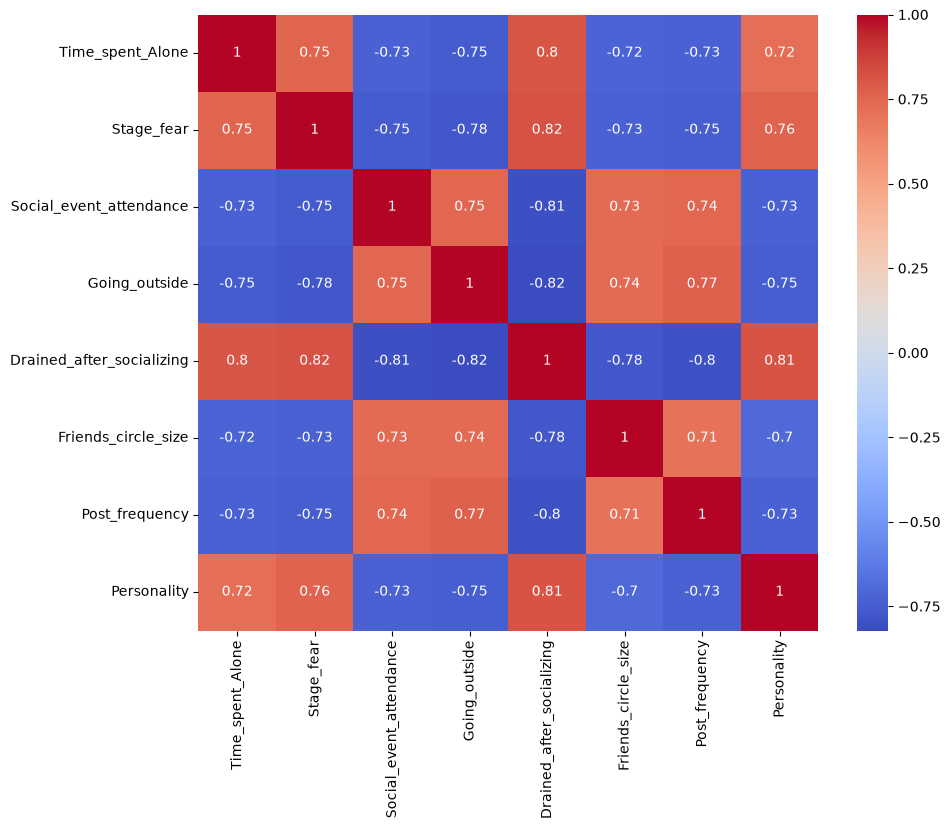

In [35]:
# Correlation matrix

corr = eda_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [36]:
# Feature Engineering
# Social Activity Score

df["Social_Activity_Score"] = (
    df["Social_event_attendance"] +
    df["Going_outside"] +
    df["Post_frequency"]
)

In [37]:
# Isolation Index

df["Isolation_Index"] = (
    df["Time_spent_Alone"] -
    df["Social_event_attendance"]
)

In [38]:
# Create a Cleaning Copy - Don't modify the original dataset directly

clean_df = df.copy()

In [39]:
# Handle Duplicate Records

duplicates = clean_df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

Duplicate rows: 388


In [40]:
# Remove duplicates values

clean_df = clean_df.drop_duplicates()

In [41]:
clean_df.duplicated().sum()

np.int64(0)

In [42]:
# Handles missing values

clean_df.isnull().sum()

Time_spent_Alone              61
Stage_fear                    73
Social_event_attendance       61
Going_outside                 65
Drained_after_socializing     51
Friends_circle_size           75
Post_frequency                63
Personality                    0
Social_Activity_Score        183
Isolation_Index              121
dtype: int64

In [43]:
# Numerical Features - Fill missing values with the median

from sklearn.impute import SimpleImputer
numeric_columns = clean_df.select_dtypes(include=['int64', 'float64']).columns

num_imputer = SimpleImputer(strategy="median")

clean_df[numeric_columns] = num_imputer.fit_transform(
    clean_df[numeric_columns]
)

In [44]:
# Categorical Features - Fill missing values with the most frequent value

categorical_columns = clean_df.select_dtypes(
    include=['object', 'string', 'category']
).columns

cat_imputer = SimpleImputer(strategy="most_frequent")

clean_df[categorical_columns] = cat_imputer.fit_transform(
    clean_df[categorical_columns]
)

In [45]:
clean_df.isnull().sum()

Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
Social_Activity_Score        0
Isolation_Index              0
dtype: int64

In [46]:
# Verify Data Types

clean_df.info()

<class 'pandas.DataFrame'>
Index: 2512 entries, 0 to 2899
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2512 non-null   float64
 1   Stage_fear                 2512 non-null   str    
 2   Social_event_attendance    2512 non-null   float64
 3   Going_outside              2512 non-null   float64
 4   Drained_after_socializing  2512 non-null   str    
 5   Friends_circle_size        2512 non-null   float64
 6   Post_frequency             2512 non-null   float64
 7   Personality                2512 non-null   str    
 8   Social_Activity_Score      2512 non-null   float64
 9   Isolation_Index            2512 non-null   float64
dtypes: float64(7), str(3)
memory usage: 215.9 KB


In [47]:
# Final Dataset Validation - verify that the cleaned dataset is ready for preprocessing

print("Shape:", clean_df.shape)

print("Missing values:")
print(clean_df.isnull().sum())

print("Duplicate rows:", clean_df.duplicated().sum())

Shape: (2512, 10)
Missing values:
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
Social_Activity_Score        0
Isolation_Index              0
dtype: int64
Duplicate rows: 13


In [48]:
print("Duplicate rows before:", clean_df.duplicated().sum())

Duplicate rows before: 13


In [49]:
clean_df = clean_df.drop_duplicates()

In [50]:
print("Duplicate rows after:", clean_df.duplicated().sum())

Duplicate rows after: 0


In [51]:
print("Shape:", clean_df.shape)

print("Missing values:")
print(clean_df.isnull().sum())

print("Duplicate rows:", clean_df.duplicated().sum())

Shape: (2499, 10)
Missing values:
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
Social_Activity_Score        0
Isolation_Index              0
dtype: int64
Duplicate rows: 0


In [52]:
# Data Preprocessing

In [53]:
# Create a Model Dataset

model_df = clean_df.copy()

In [54]:
# Inspect Data Types

model_df.info()

<class 'pandas.DataFrame'>
Index: 2499 entries, 0 to 2899
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2499 non-null   float64
 1   Stage_fear                 2499 non-null   str    
 2   Social_event_attendance    2499 non-null   float64
 3   Going_outside              2499 non-null   float64
 4   Drained_after_socializing  2499 non-null   str    
 5   Friends_circle_size        2499 non-null   float64
 6   Post_frequency             2499 non-null   float64
 7   Personality                2499 non-null   str    
 8   Social_Activity_Score      2499 non-null   float64
 9   Isolation_Index            2499 non-null   float64
dtypes: float64(7), str(3)
memory usage: 214.8 KB


In [55]:
# Identify Feature Types

categorical_columns = model_df.select_dtypes(include=["object", "string", "str"]).columns.tolist()

numeric_columns = model_df.select_dtypes(include=["number"]).columns.tolist()

print("Categorical Features:", categorical_columns)
print("Numerical Features:", numeric_columns)

Categorical Features: ['Stage_fear', 'Drained_after_socializing', 'Personality']
Numerical Features: ['Time_spent_Alone', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency', 'Social_Activity_Score', 'Isolation_Index']


In [56]:
# Encode Binary Features

# Suppose your dataset contains:Yes and No

# Machine learning models cannot process text values. so Convert them into numbers.

binary_mapping = {
    "Yes": 1,
    "No": 0
}

binary_features = [
    "Stage_fear",
    "Drained_after_socializing"
]

for column in binary_features:
    model_df[column] = model_df[column].map(binary_mapping)

In [57]:
# Encode the Target Variable
# The target is - Introvert, Extrovert
# Convert it into numbers.

from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

model_df["Personality"] = target_encoder.fit_transform(
    model_df["Personality"]
)

In [58]:
# Inspect the encoding

print(target_encoder.classes_)

['Extrovert' 'Introvert']


In [59]:
# Save the encoder for deployment.

joblib.dump(target_encoder, "../model/target_encoder.pkl")

['../model/target_encoder.pkl']

In [60]:
# Verify Encoding

model_df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality,Social_Activity_Score,Isolation_Index
0,4.0,0,4.0,6.0,0,13.0,5.0,0,15.0,0.0
1,9.0,1,0.0,0.0,1,0.0,3.0,1,3.0,9.0
2,9.0,1,1.0,2.0,1,5.0,2.0,1,5.0,8.0
3,0.0,0,6.0,7.0,0,14.0,8.0,0,21.0,-6.0
4,3.0,0,9.0,4.0,0,8.0,5.0,0,18.0,-6.0


In [61]:
model_df.info()

<class 'pandas.DataFrame'>
Index: 2499 entries, 0 to 2899
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2499 non-null   float64
 1   Stage_fear                 2499 non-null   int64  
 2   Social_event_attendance    2499 non-null   float64
 3   Going_outside              2499 non-null   float64
 4   Drained_after_socializing  2499 non-null   int64  
 5   Friends_circle_size        2499 non-null   float64
 6   Post_frequency             2499 non-null   float64
 7   Personality                2499 non-null   int64  
 8   Social_Activity_Score      2499 non-null   float64
 9   Isolation_Index            2499 non-null   float64
dtypes: float64(7), int64(3)
memory usage: 214.8 KB


In [62]:
# Separate Features and Target
# Features : x and Target : y


X = model_df.drop("Personality", axis=1)
y = model_df["Personality"]

In [63]:
# Check 

print(X.head())
print(y.head())

   Time_spent_Alone  Stage_fear  Social_event_attendance  Going_outside  \
0               4.0           0                      4.0            6.0   
1               9.0           1                      0.0            0.0   
2               9.0           1                      1.0            2.0   
3               0.0           0                      6.0            7.0   
4               3.0           0                      9.0            4.0   

   Drained_after_socializing  Friends_circle_size  Post_frequency  \
0                          0                 13.0             5.0   
1                          1                  0.0             3.0   
2                          1                  5.0             2.0   
3                          0                 14.0             8.0   
4                          0                  8.0             5.0   

   Social_Activity_Score  Isolation_Index  
0                   15.0              0.0  
1                    3.0              9.0  
2 

In [64]:
# Verify the shapes

print("Features:", X.shape)
print("Target:", y.shape)

Features: (2499, 9)
Target: (2499,)


In [65]:
# Train-Test Split - split the data into training and testing sets.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [66]:
# Verify the split

print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (1999, 9)
Testing Features: (500, 9)
Training Labels: (1999,)
Testing Labels: (500,)


In [67]:
# Create scaled versions only for Logistic Regression.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [68]:
# Save the scaler as well

joblib.dump(scaler, "../model/scaler.pkl")

['../model/scaler.pkl']

In [69]:
# Baseline Model: Logistic Regression

In [70]:
# Import the Model

from sklearn.linear_model import LogisticRegression

In [71]:
# Create the Model

lr_model = LogisticRegression(
    random_state=42
)

In [72]:
# Train the Model

lr_model.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [73]:
# Make Predictions
# test on unseen data.

lr_predictions = lr_model.predict(
    X_test_scaled
)

In [74]:
print(lr_predictions[:10])

[1 0 0 1 0 1 0 0 1 0]


In [78]:
# Evaluate Performance - calculate **Accuracy**, **Precision**, **Recall**, **F1-score**, **Confusion Matrix**, **ROC-AUC**

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Accuracy

lr_accuracy = accuracy_score(
    y_test,
    lr_predictions
)

print(f"Accuracy : {lr_accuracy:.4f}")


# Precision

lr_precision = precision_score(
    y_test,
    lr_predictions
)

print(f"Precision : {lr_precision:.4f}")


# Recall
lr_recall = recall_score(
    y_test,
    lr_predictions
)

print(f"Recall : {lr_recall:.4f}")


# F1 Score

lr_f1 = f1_score(
    y_test,
    lr_predictions
)

print(f"F1 Score : {lr_f1:.4f}")


# ROC-AUC
# Instead of hard class labels, ROC-AUC evaluates how well the model separates the two classes across different decision thresholds.

# First obtain prediction probabilities.

lr_probabilities = lr_model.predict_proba(
    X_test_scaled
)[:, 1]

# Then calculate ROC-AUC.

lr_auc = roc_auc_score(
    y_test,
    lr_probabilities
)

print(f"ROC-AUC : {lr_auc:.4f}")


Accuracy : 0.9240
Precision : 0.9289
Recall : 0.8950
F1 Score : 0.9116
ROC-AUC : 0.9496


In [79]:
# Classification Report

print(
    classification_report(
        y_test,
        lr_predictions,
        target_names=["Extrovert", "Introvert"]
    )
)

              precision    recall  f1-score   support

   Extrovert       0.92      0.95      0.93       281
   Introvert       0.93      0.89      0.91       219

    accuracy                           0.92       500
   macro avg       0.92      0.92      0.92       500
weighted avg       0.92      0.92      0.92       500



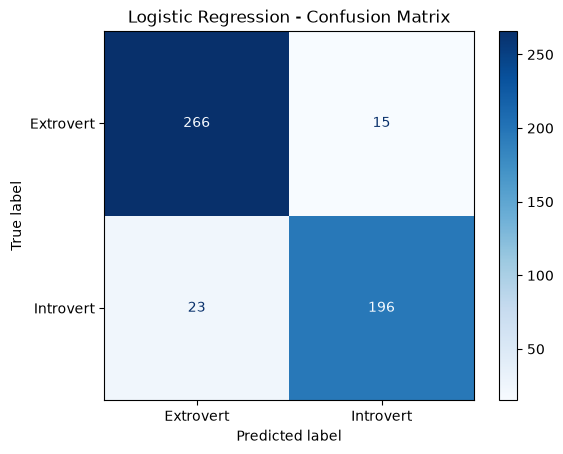

In [81]:
# Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Extrovert", "Introvert"]
).plot(cmap="Blues")

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [82]:
# Store the Results

model_results = []

model_results.append({
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1 Score": lr_f1,
    "ROC-AUC": lr_auc
})

In [84]:
# save baseline model (logistic regression model)

joblib.dump(lr_model, "../model/logistic_regression.pkl")

['../model/logistic_regression.pkl']

In [85]:
# Random Forest model (Ensemble Model)

In [86]:
# Import Random Forest

from sklearn.ensemble import RandomForestClassifier

In [87]:
# Create the Model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [88]:
# Train the Model
# Use the unscaled training data.

rf_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [89]:
# Make Predictions

rf_predictions = rf_model.predict(
    X_test
)

In [90]:
# Prediction probabilities

rf_probabilities = rf_model.predict_proba(
    X_test
)[:,1]

In [91]:
# Evaluate Performance

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Accuracy
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(f"Accuracy : {rf_accuracy:.4f}")


# Precision
rf_precision = precision_score(
    y_test,
    rf_predictions
)

print(f"Precision : {rf_precision:.4f}")


# Recall
rf_recall = recall_score(
    y_test,
    rf_predictions
)

print(f"Recall : {rf_recall:.4f}")


# F1 Score
rf_f1 = f1_score(
    y_test,
    rf_predictions
)

print(f"F1 Score : {rf_f1:.4f}")


# ROC-AUC
rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

print(f"ROC-AUC : {rf_auc:.4f}")

Accuracy : 0.9140
Precision : 0.9190
Recall : 0.8813
F1 Score : 0.8998
ROC-AUC : 0.9496


In [92]:
# Classification Report

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=["Extrovert", "Introvert"]
    )
)

              precision    recall  f1-score   support

   Extrovert       0.91      0.94      0.92       281
   Introvert       0.92      0.88      0.90       219

    accuracy                           0.91       500
   macro avg       0.91      0.91      0.91       500
weighted avg       0.91      0.91      0.91       500



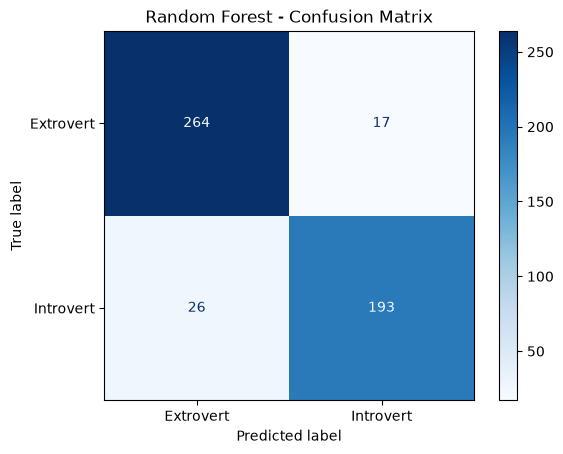

In [93]:
# Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    rf_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Extrovert", "Introvert"]
).plot(cmap="Blues")

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [94]:
# Feature Importance 
# Random Forest provides feature importance, which is valuable for explaining the model.

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Stage_fear,0.259799
4,Drained_after_socializing,0.173959
0,Time_spent_Alone,0.137589
6,Post_frequency,0.089486
2,Social_event_attendance,0.085479
5,Friends_circle_size,0.076591
3,Going_outside,0.072214
8,Isolation_Index,0.059852
7,Social_Activity_Score,0.045032


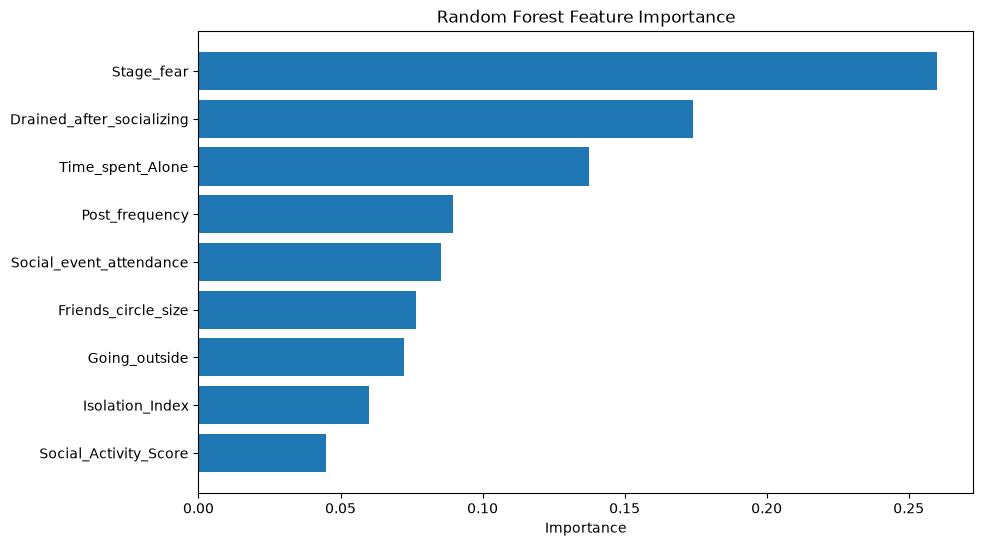

In [95]:
# Visualize it.

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.show()

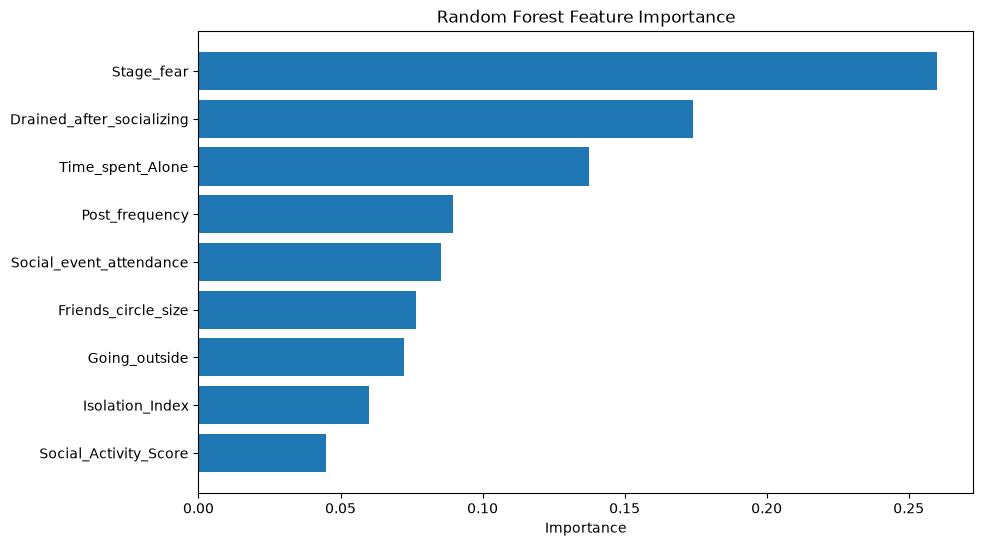

In [96]:
# visualize it

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Random Forest Feature Importance")

plt.xlabel("Importance")

plt.show()

In [97]:
# Add Results to Comparison Table

model_results.append({
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1,
    "ROC-AUC": rf_auc
})

In [98]:
# Compare with Logistic Regression
# Create a comparison DataFrame.

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.924,0.928910,0.894977,0.911628,0.949634
1,Random Forest,0.914,0.919048,0.881279,0.899767,0.949569


In [99]:
# Save the Random forest Model in to model folder

joblib.dump(rf_model,"../model/random_forest.pkl")

['../model/random_forest.pkl']

In [100]:
# XGBoost Classifier (Boosting model)

In [101]:
# Import XGBoost

from xgboost import XGBClassifier

In [102]:
# Create the Model

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

In [103]:
# Train the Model
# Use the unscaled data.

xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [104]:
# Make Predictions

xgb_predictions = xgb_model.predict(
    X_test
)

# Prediction probabilities

xgb_probabilities = xgb_model.predict_proba(
    X_test
)[:, 1]

In [105]:
# Evaluate Performance

# Accuracy
xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

print(f"Accuracy : {xgb_accuracy:.4f}")

# Precision
xgb_precision = precision_score(
    y_test,
    xgb_predictions
)

print(f"Precision : {xgb_precision:.4f}")

# Recall
xgb_recall = recall_score(
    y_test,
    xgb_predictions
)

print(f"Recall : {xgb_recall:.4f}")


# F1 Score
xgb_f1 = f1_score(
    y_test,
    xgb_predictions
)

print(f"F1 Score : {xgb_f1:.4f}")


# ROC-AUC
xgb_auc = roc_auc_score(
    y_test,
    xgb_probabilities
)

print(f"ROC-AUC : {xgb_auc:.4f}")

Accuracy : 0.9340
Precision : 0.9227
Recall : 0.9269
F1 Score : 0.9248
ROC-AUC : 0.9668


In [106]:
# Classification Report

print(
    classification_report(
        y_test,
        xgb_predictions,
        target_names=["Extrovert", "Introvert"]
    )
)

              precision    recall  f1-score   support

   Extrovert       0.94      0.94      0.94       281
   Introvert       0.92      0.93      0.92       219

    accuracy                           0.93       500
   macro avg       0.93      0.93      0.93       500
weighted avg       0.93      0.93      0.93       500



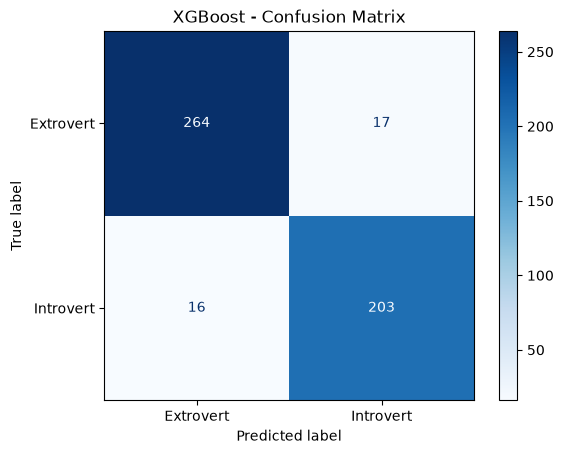

In [107]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    xgb_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Extrovert", "Introvert"]
).plot(cmap="Blues")

plt.title("XGBoost - Confusion Matrix")

plt.show()

In [108]:
# Feature Importance

feature_importance_xgb = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_xgb

,Feature,Importance
1,Stage_fear,0.958550
6,Post_frequency,0.012128
2,Social_event_attendance,0.004779
5,Friends_circle_size,0.004305
7,Social_Activity_Score,0.004274
3,Going_outside,0.004256
0,Time_spent_Alone,0.004126
4,Drained_after_socializing,0.003834
8,Isolation_Index,0.003748


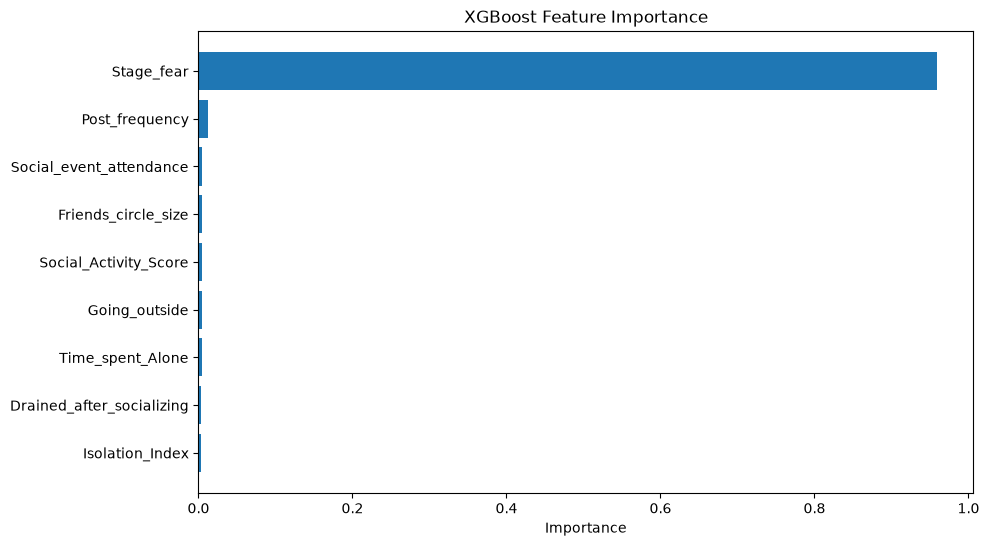

In [109]:
# Visualization

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_xgb["Feature"],
    feature_importance_xgb["Importance"]
)

plt.gca().invert_yaxis()

plt.title("XGBoost Feature Importance")

plt.xlabel("Importance")

plt.show()

In [110]:
# Update Comparison Table

model_results.append({
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1 Score": xgb_f1,
    "ROC-AUC": xgb_auc
})

In [111]:
# Recreate the comparison table.

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.934,0.922727,0.926941,0.924829,0.966842
1,Logistic Regression,0.924,0.928910,0.894977,0.911628,0.949634
2,Random Forest,0.914,0.919048,0.881279,0.899767,0.949569


In [112]:
# Save the Model

joblib.dump(xgb_model,"../model/xgboost.pkl")

['../model/xgboost.pkl']